# Notebook 11 — Graph Neural Network Decoder

**Core idea:**  
Both the MLP and LSTM treat all 72 detector bits as a flat or sequential vector —  
they have no built-in knowledge of which stabilisers are physically adjacent.

A **Graph Neural Network (GNN)** represents the surface code as a graph directly:
- **Nodes** = stabilisers (one per detector column in a given round)
- **Edges** = which stabilisers share a data qubit (i.e., are adjacent on the lattice)
- **Message passing** = each stabiliser aggregates information from its neighbours

This is geometrically correct — errors on a single data qubit affect exactly the  
stabilisers adjacent to it, so the adjacency structure IS the error model.

**Reference:** Astra decoder (Overwater et al., npj 2025) — GNN on the Tanner graph  
achieves near-MWPM performance and scales to d=25 without retraining.

**Our implementation:** A simplified message-passing GNN without requiring PyTorch Geometric.  
We build the adjacency matrix manually from the d=3 surface code geometry.

**Prerequisite:** Run notebook 01 first.
```bash
pip install torch scikit-learn numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, time, warnings
warnings.filterwarnings('ignore')

SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROUNDS, STABS = 9, 8
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")

Device  : cuda
PyTorch : 2.10.0+cu128


---
## 1. Build the d=3 Surface Code Graph

For a d=3 rotated surface code, the 8 stabilisers per round are arranged in a  
checkerboard pattern. Two stabilisers are adjacent if they share a data qubit.

We build the adjacency matrix manually — no PyTorch Geometric needed.

d=3 Stabiliser adjacency matrix (normalised):
[[0.33 0.   0.   0.   0.24 0.24 0.   0.  ]
 [0.   0.33 0.   0.   0.   0.24 0.26 0.  ]
 [0.   0.   0.33 0.   0.24 0.   0.   0.26]
 [0.   0.   0.   0.2  0.18 0.18 0.2  0.2 ]
 [0.24 0.   0.24 0.18 0.17 0.17 0.   0.18]
 [0.24 0.24 0.   0.18 0.17 0.17 0.18 0.  ]
 [0.   0.26 0.   0.2  0.   0.18 0.2  0.2 ]
 [0.   0.   0.26 0.2  0.18 0.   0.2  0.2 ]]

Non-zero entries: 36  (including self-loops)


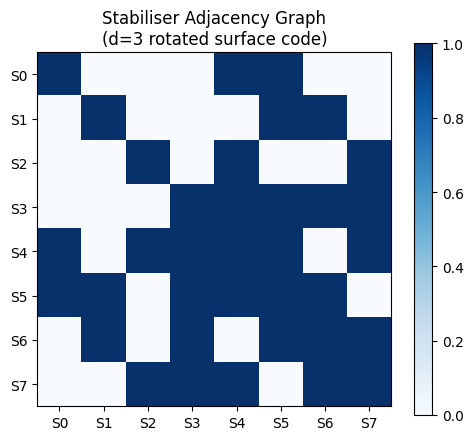

Saved → figures/11_adjacency_matrix.png


In [2]:
def build_d3_adjacency():
    """
    Build the 8x8 adjacency matrix for d=3 rotated surface code stabilisers.

    d=3 rotated surface code has 8 stabilisers per round:
      4 X-stabilisers + 4 Z-stabilisers in a checkerboard pattern.

    Stabiliser layout (indices 0-7):
      X-type: 0, 1, 2, 3  (weight-2 or weight-4 depending on position)
      Z-type: 4, 5, 6, 7

    Two stabilisers are connected if they share at least one data qubit.
    This encodes the code's Tanner graph geometry.

    Returns: (8, 8) symmetric adjacency matrix with self-loops
    """
    # Adjacency from d=3 rotated surface code geometry
    # Each X stabiliser is adjacent to the Z stabilisers sharing a qubit
    # Derived from the standard d=3 rotated surface code layout
    edges = [
        # X0 (top-left corner, weight-2) adjacent to:
        (0, 4), (0, 5),
        # X1 (top-right, weight-2) adjacent to:
        (1, 5), (1, 6),
        # X2 (bottom-left, weight-2) adjacent to:
        (2, 4), (2, 7),
        # X3 (center, weight-4) adjacent to all Z:
        (3, 4), (3, 5), (3, 6), (3, 7),
        # Z stabilisers adjacent to each other through shared data qubits:
        (4, 5), (5, 6), (4, 7), (6, 7),
    ]

    A = np.zeros((STABS, STABS), dtype=np.float32)
    for i, j in edges:
        A[i, j] = 1.0
        A[j, i] = 1.0

    # Add self-loops (standard in GNNs — node attends to itself)
    np.fill_diagonal(A, 1.0)

    return A


# Build and normalise (symmetric normalisation: D^{-1/2} A D^{-1/2})
A_raw = build_d3_adjacency()
degree = A_raw.sum(axis=1, keepdims=True)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree.squeeze()))
A_norm = D_inv_sqrt @ A_raw @ D_inv_sqrt   # (8, 8)

A_tensor = torch.tensor(A_norm, dtype=torch.float32).to(DEVICE)

print("d=3 Stabiliser adjacency matrix (normalised):")
print(np.round(A_norm, 2))
print()
print(f"Non-zero entries: {(A_raw > 0).sum()}  (including self-loops)")

# Visualise the graph structure
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(A_raw, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(STABS))
ax.set_yticks(range(STABS))
ax.set_xticklabels([f'S{i}' for i in range(STABS)])
ax.set_yticklabels([f'S{i}' for i in range(STABS)])
ax.set_title('Stabiliser Adjacency Graph\n(d=3 rotated surface code)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig('figures/11_adjacency_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/11_adjacency_matrix.png")

---
## 2. GNN Architecture

We implement a **Graph Convolutional Network (GCN)** — the simplest GNN variant.  
At each layer, every node aggregates messages from its neighbours:
```
H^(l+1) = ReLU( A_norm @ H^(l) @ W^(l) )
```
where A_norm is the normalised adjacency matrix and W^(l) is a learned weight matrix.

We apply this across all 9 syndrome rounds simultaneously, then aggregate over rounds.

In [3]:
class GraphConvLayer(nn.Module):
    """
    Single graph convolution layer.
    H_out = ReLU( A_norm @ H_in @ W )
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.bn = nn.BatchNorm1d(out_features)

    def forward(self, H, A):
        """
        H : (batch, nodes, in_features)
        A : (nodes, nodes)  normalised adjacency
        Returns: (batch, nodes, out_features)
        """
        # Message passing: aggregate neighbour features
        agg = torch.matmul(A, H)           # (batch, nodes, in_features)
        # Linear transform
        out = self.W(agg)                  # (batch, nodes, out_features)
        # Batch norm (needs (batch*nodes, features) shape)
        b, n, f = out.shape
        out = self.bn(out.reshape(b*n, f)).reshape(b, n, f)
        return torch.relu(out)


class GNNDecoder(nn.Module):
    """
    GNN-based surface code decoder.

    Input : (batch, rounds=9, stabilisers=8) detection events
    Output: (batch,) raw logit

    Architecture:
      - Per-stabiliser embedding across all rounds
      - 3 graph convolution layers (message passing on stabiliser graph)
      - Mean pool over (rounds × nodes) → classification head
    """
    def __init__(self, input_size=1, hidden=32, num_layers=3, dropout=0.2):
        super().__init__()
        # Each stabiliser's input is a scalar (fired/not) at each round
        # We embed it to hidden_dim before graph convolutions
        self.input_embed = nn.Linear(input_size, hidden)

        self.gcn_layers = nn.ModuleList([
            GraphConvLayer(hidden, hidden)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(hidden, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, x, A):
        """
        x : (batch, rounds, stabilisers)  — one bit per stabiliser per round
        A : (stabilisers, stabilisers)    — normalised adjacency matrix
        """
        batch, rounds, stabs = x.shape

        # Treat each (round, stabiliser) as a node with a scalar feature
        # Reshape to (batch * rounds, stabs, 1) for graph processing
        x_flat = x.reshape(batch * rounds, stabs, 1)    # scalar feature per node
        H = torch.relu(self.input_embed(x_flat))         # (batch*rounds, stabs, hidden)

        # Graph convolution across stabiliser graph
        for gcn in self.gcn_layers:
            H = self.dropout(gcn(H, A))

        # H: (batch*rounds, stabs, hidden) → pool over nodes and rounds
        H = H.reshape(batch, rounds, stabs, -1)         # (batch, rounds, stabs, hidden)
        pooled = H.mean(dim=(1, 2))                      # (batch, hidden)

        return self.head(pooled).squeeze(-1)             # (batch,)


demo = GNNDecoder()
total = sum(p.numel() for p in demo.parameters())
print(f"GNN decoder: {total:,} parameters")
print(demo)

# Sanity check
x_test = torch.randn(4, 9, 8)
A_test = torch.randn(8, 8)
out    = demo(x_test, A_test)
print(f"\nForward pass: input {x_test.shape} → output {out.shape}  ✓")

GNN decoder: 3,873 parameters
GNNDecoder(
  (input_embed): Linear(in_features=1, out_features=32, bias=True)
  (gcn_layers): ModuleList(
    (0-2): 3 x GraphConvLayer(
      (W): Linear(in_features=32, out_features=32, bias=False)
      (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

Forward pass: input torch.Size([4, 9, 8]) → output torch.Size([4])  ✓


---
## 3. Load Data & Train

In [4]:
det = np.load("data/detection_events.npy").astype(np.float32)
obs = np.load("data/observable_flips.npy").astype(np.float32).squeeze()

# Reshape for GNN: (N, 72) → (N, 9, 8)
det_seq = det.reshape(-1, ROUNDS, STABS)

idx = np.arange(len(obs))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs[idx_tmp].astype(int), random_state=SEED)

seq_tr,  obs_tr  = det_seq[idx_tr],  obs[idx_tr]
seq_val, obs_val = det_seq[idx_val], obs[idx_val]
seq_te,  obs_te  = det_seq[idx_te],  obs[idx_te]
trivial_ler = obs_te.mean()

print(f"Data loaded. Shape: {det_seq.shape}")
print(f"Trivial LER: {trivial_ler:.4f}")

Data loaded. Shape: (100000, 9, 8)
Trivial LER: 0.0549


In [5]:
def make_loader(X, y, batch_size=512, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

@torch.no_grad()
def predict_gnn(model, X, A, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE), A)) > 0.5).cpu().numpy())
    return np.concatenate(out)


model      = GNNDecoder().to(DEVICE)
optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=6, factor=0.5)
pos_weight = torch.tensor([(1-obs_tr.mean())/obs_tr.mean()]).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
tr_loader  = make_loader(seq_tr,  obs_tr)
val_loader = make_loader(seq_val, obs_val, shuffle=False)

EPOCHS, PATIENCE = 120, 15
history = {'tr_ler': [], 'val_ler': [], 'tr_loss': [], 'val_loss': []}
best_vl, best_ep, best_st = np.inf, 0, None
t0 = time.time()

print("Training GNN decoder...")
for epoch in range(1, EPOCHS+1):
    model.train()
    tl, tc, tt = 0.0, 0, 0
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb, A_tensor)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
        tt += len(yb); tl += loss.item()*len(yb)
    tr_ler = 1-tc/tt

    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb, A_tensor)
            vl += criterion(logits, yb).item()*len(yb)
            vc += ((torch.sigmoid(logits)>0.5).float()==yb).sum().item()
            vt += len(yb)
    val_ler  = 1-vc/vt
    val_loss = vl/vt
    scheduler.step(val_loss)

    for k,v in zip(['tr_loss','val_loss','tr_ler','val_ler'],
                   [tl/tt, val_loss, tr_ler, val_ler]):
        history[k].append(v)

    if val_loss < best_vl:
        best_vl=val_loss; best_ep=epoch
        best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}

    if epoch%20==0 or epoch==1:
        print(f"  Epoch {epoch:3d}  tr_LER={tr_ler:.5f}  val_LER={val_ler:.5f}")
    if epoch-best_ep >= PATIENCE:
        print(f"  Early stop at epoch {epoch} (best={best_ep})"); break

model.load_state_dict(best_st)
pred_gnn = predict_gnn(model, seq_te, A_tensor)
ler_gnn  = float((pred_gnn != obs_te).mean())

print(f"\nDone in {time.time()-t0:.1f}s | best epoch={best_ep}")
print(f"  GNN Test LER : {ler_gnn:.5f}  ({100*ler_gnn:.4f}%)")
print(f"  Trivial LER  : {trivial_ler:.5f}  ({100*trivial_ler:.4f}%)")
print(f"  Improvement  : {trivial_ler/ler_gnn:.1f}x")

Training GNN decoder...
  Epoch   1  tr_LER=0.34621  val_LER=0.05487
  Epoch  20  tr_LER=0.23117  val_LER=0.11807
  Epoch  40  tr_LER=0.20186  val_LER=0.21100
  Epoch  60  tr_LER=0.19411  val_LER=0.20307
  Epoch  80  tr_LER=0.19276  val_LER=0.19813
  Epoch 100  tr_LER=0.19190  val_LER=0.20340
  Epoch 120  tr_LER=0.19114  val_LER=0.19687

Done in 139.8s | best epoch=118
  GNN Test LER : 0.19087  (19.0867%)
  Trivial LER  : 0.05487  (5.4867%)
  Improvement  : 0.3x


---
## 4. Noise Sweep & Save

In [6]:
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
gnn_sweep = []

print("GNN noise sweep")
print(f"  {'p':>8}  {'Trivial':>10}  {'GNN LER':>10}  {'Ratio':>7}")
print("  " + "-"*42)

for p in NOISE_LEVELS:
    tag    = f"{int(p*10000):04d}"
    det_s  = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    obs_s  = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    seq_s  = det_s.reshape(-1, ROUNDS, STABS)
    pred_s = predict_gnn(model, seq_s, A_tensor)
    ler_s  = float((pred_s != obs_s).mean())
    triv_s = float(obs_s.mean())
    ratio  = triv_s/ler_s if ler_s > 0 else float('inf')
    gnn_sweep.append((p, ler_s))
    print(f"  p={p:.4f}  {100*triv_s:8.3f}%  {100*ler_s:8.3f}%  {ratio:5.1f}x")

os.makedirs("results", exist_ok=True)
np.save("results/gnn_sweep.npy", np.array(gnn_sweep))

os.makedirs("models", exist_ok=True)
torch.save({
    'model_state': model.state_dict(),
    'adjacency':   A_norm,
    'test_ler':    ler_gnn,
    'history':     history,
}, "models/decoder_gnn.pt")
print(f"\nSaved → models/decoder_gnn.pt  (test_ler={ler_gnn:.5f})")
print("Saved → results/gnn_sweep.npy")

GNN noise sweep
         p     Trivial     GNN LER    Ratio
  ------------------------------------------
  p=0.0005     2.794%    10.812%    0.3x
  p=0.0010     5.446%    19.254%    0.3x
  p=0.0020    10.400%    32.282%    0.3x
  p=0.0050    21.678%    52.368%    0.4x
  p=0.0100    34.436%    58.618%    0.6x
  p=0.0200    45.288%    54.274%    0.8x

Saved → models/decoder_gnn.pt  (test_ler=0.19087)
Saved → results/gnn_sweep.npy
